# Fairlearn

In [3]:
!pip install fairlearn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [47]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from fairlearn.metrics import MetricFrame, selection_rate

In [10]:
df = pd.read_csv('../data.csv')
X = df.drop(['species'],axis=1)
y = df['species']

### Introduce a “location” attribute in IRIS dataset

In [15]:
X['location'] = np.random.randint(0, 2, size=len(X))

# Sensitive attribute (not used for training)
A = X["location"]

# Remove sensitive attribute for model input
X_nosensitive = X.drop(columns=["location"])

In [16]:
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X_nosensitive, y, A, test_size=0.3, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [23]:
import fairlearn
print(fairlearn.__version__)

0.13.0


In [26]:
mf = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
    },
    y_true=y_test,
    y_pred=preds,
    sensitive_features=A_test
)

print("=== Overall Metrics ===")
print(mf.overall)

print("\n=== Metrics by Location Group ===")
print(mf.by_group)

print("\n=== Group Differences (fairness gaps) ===")
print(mf.difference())

=== Overall Metrics ===
accuracy          0.83871
selection_rate    0.00000
dtype: float64

=== Metrics by Location Group ===
          accuracy  selection_rate
location                          
0         0.923077             0.0
1         0.777778             0.0

=== Group Differences (fairness gaps) ===
accuracy          0.145299
selection_rate    0.000000
dtype: float64


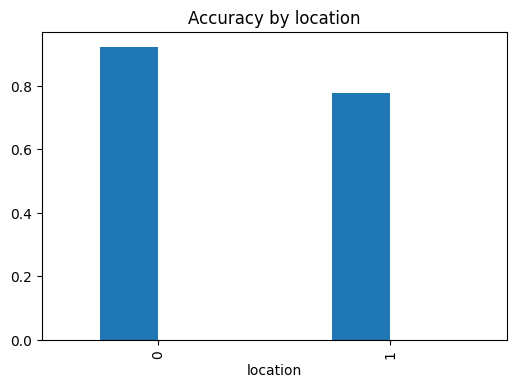

In [38]:
mf.by_group.plot(kind='bar', figsize=[6, 4], legend=False, title="Accuracy by location");

# SHAP

A SHAP value tells you:

Positive SHAP value → Feature pushes the model towards Virginica

Negative SHAP value → Feature pushes the model away from Virginica

In [41]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 20.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 100.4 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:m╺━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
      Successfully uninstalled numpy-2.2.6━━━━━━━━━━━━━━━━━━━━ 1/3 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [shap]2/3 [shap]]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
feast 0.54.0 requires pydantic==2.10.6, but you have pydantic 2.12.3 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [52]:
!pip install "numpy<=2.1.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 80.6 MB/s  0:00:006m0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.3
    Uninstalling numpy-2.1.3:
      Successfully uninstalled numpy-2.1.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
feast 0.54.0 requires pydantic==2.10.6, but you have pydantic 2.12.3 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [55]:
!pip install --upgrade numba

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 55.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 84.9 MB/s  0:00:006m0:00:0100:01
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.44.0
    Uninstalling llvmlite-0.44.0:
      Successfully uninstalled llvmlite-0.44.0
  Attempting uninstall: numba━━━━━━━━━━━━━━━━━━━ 0/2 [llvmlite]
    Found existing installation: numba 0.61.0 0/2 [llvmlite]
    Uninstalling numba-0.61.0:0m╺━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
      Successfully uninstalled numba-0.61.0━━━━━━━━━━━━━━━━━━━ 1/2 [numba]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [numba]32m1/2 [numba]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.16.1 requires numba<=0.61,>=0.56.0, but you have numba 0.62.1 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 25.3
[n

In [56]:
import shap

In [45]:
df = pd.read_csv('../data.csv')
X = df.drop(['species'],axis=1)
y = df['species']

In [48]:
# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Class order:", le.classes_)

# Get Virginica index
class_idx = list(le.classes_).index("virginica")
print("Virginica index:", class_idx)

Class order: ['setosa' 'versicolor' 'virginica']
Virginica index: 2


In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


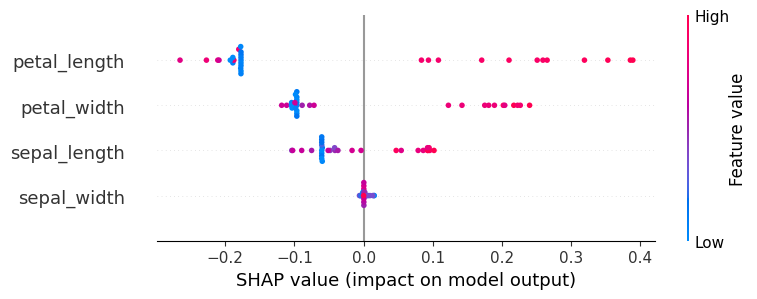

In [65]:
# SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)

# SHAP Summary Plot for Virginica
shap.summary_plot(shap_values.values[:,:,class_idx], X_test);

Longer petals strongly push the model toward predicting Virginica. Shorter petals push it away.  
Wider petals make the model more confident it’s Virginica.  
Sepal length has only a small influence.  
Sepal width barely affects the Virginica prediction at all.

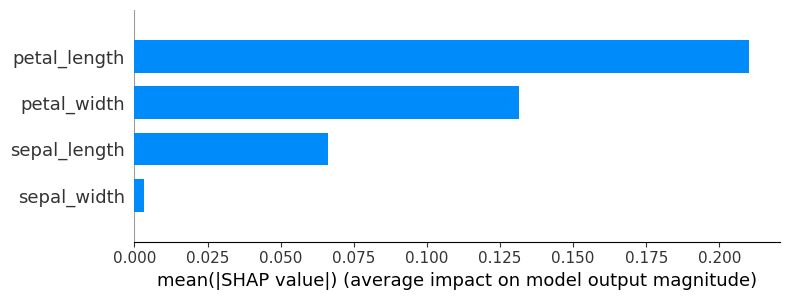

In [67]:
shap.summary_plot(shap_values.values[:,:,class_idx], X_test, plot_type="bar");

The model relies heavily on petal length.  
Petal width is the second most influential feature.  

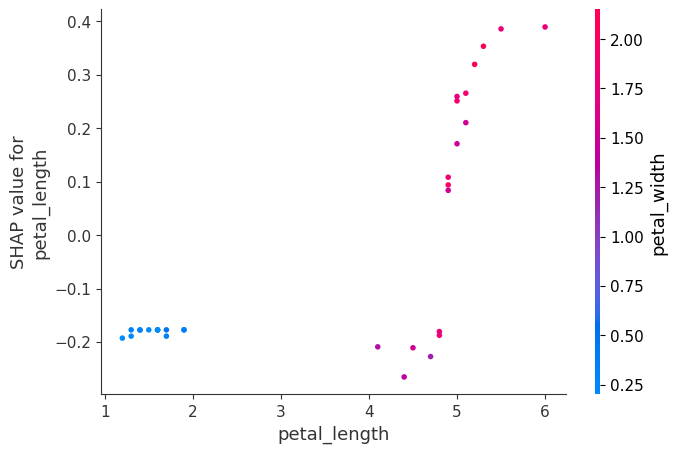

In [85]:
shap.dependence_plot(
    "petal_length",
    shap_values.values[:,:,class_idx],
    X_test
);

In [77]:
shap.initjs()
fp = shap.force_plot(
    explainer.expected_value[class_idx],
    shap_values.values[0,:,class_idx],
    X_test.iloc[0]
);
display(fp)

Force plot for single prediction  
Before looking at any features, the model’s average output for Virginica is ~0.2.  
sepal_length 6.3 - Big red arrow - Pushes prediction strongly higher  
petal_length 5.1 - Pushes prediction even more toward Virginica  
petal_width 1.5 - Pulls down  
The model thinks there is a 50% probability for this flower to be Virginica

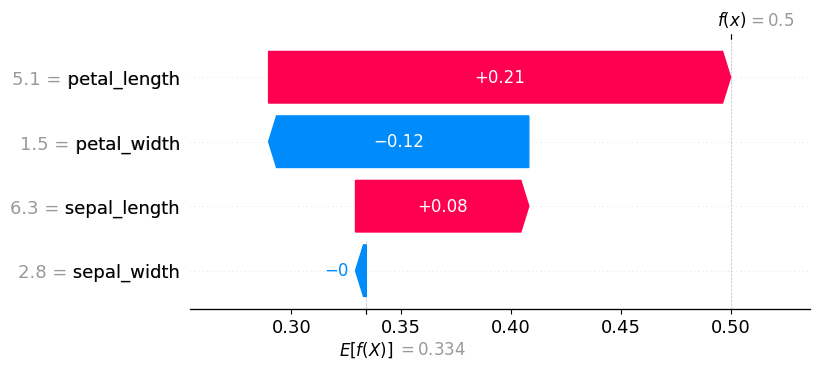

In [84]:
shap_explanation = shap.Explanation(
    values = shap_values.values[0, :, class_idx],
    base_values = explainer.expected_value[class_idx],
    data = X_test.iloc[0,:].values,
    feature_names = X_test.columns
)
shap.plots.waterfall(shap_explanation)

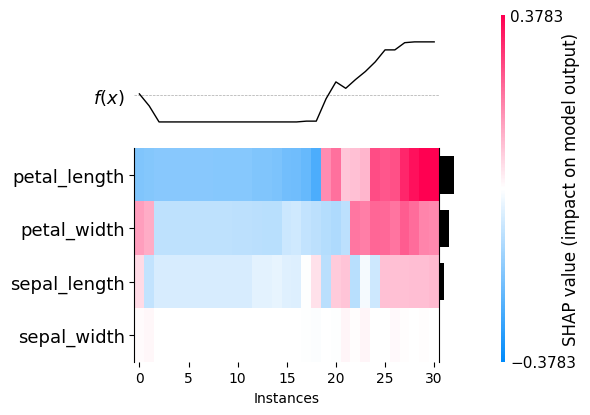

In [82]:
shap.plots.heatmap(shap_values[:,:,class_idx]);

petal_length : Strongest feature, consistent and clear pattern.  
petal_width : Similar pattern - blue on left, red on right, but slightly weaker than petal_length  
sepal_length : Some influence, but much weaker than petal measurements  
sepal_width : Mostly white with tiny splashes of color , almost no effect on prediction, Negligible feature

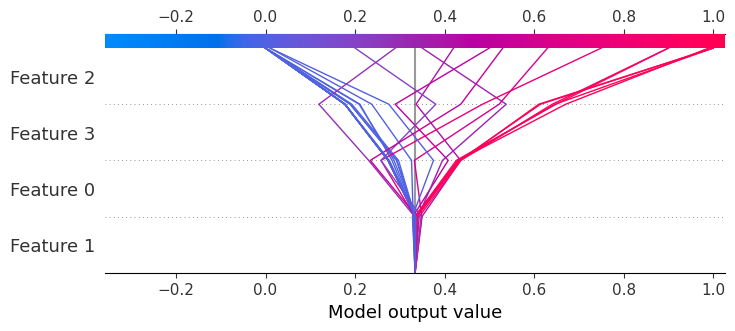

In [87]:
shap.plots.decision(
    explainer.expected_value[class_idx],         # base value (scalar)
    shap_values.values[:,:,class_idx]            # shap values for Virginica
)

How each feature contributes to the prediction for many samples.  
Shows the “decision path” from the base value to the final model output  
Each colored line = one flower  
At “Feature 1” all samples start from a common baseline (the average predicted probability).
All lines spread out at the top:  
Far right → samples predicted as Virginica  
Middle → uncertain  
Left → samples predicted not Virginica